# 🏠 House Price Classification  
## Machine Learning – Predicting Above/Below Median House Prices

⚠️ **Urheberrechtshinweis**  
Dieses Notebook ist urheberrechtlich geschützt. Nutzung ausschließlich zur Evaluation.  
Keine Weitergabe, Modifikation oder Veröffentlichung ohne schriftliche Zustimmung der Autorin.

---

## 📌 Überblick  
Dieses Notebook zeigt einen vollständigen Machine‑Learning‑Workflow zur Klassifikation von Immobilienpreisen (über/unter Median) basierend auf dem **Ames Housing Dataset**.

Der Workflow umfasst:
- Datenimport  
- Datenbereinigung  
- Explorative Datenanalyse (EDA)  
- Feature Engineering  
- Modelltraining  
- Modellvergleich  
- Evaluation  

Die Daten stammen aus dem frei verfügbaren Ames Housing Datensatz (Open Data).

In [2]:
# Copyright © 2026 Marijke Haupt
# Nutzung ausschließlich zur Evaluation. Keine Weitergabe oder Modifikation ohne Zustimmung.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## 📁 Daten laden  
Wir verwenden den Ames Housing Datensatz (Open Data).  
Der originale Datensatz wurde für dieses Projekt gekürzt. 
Die Datei befindet sich im Ordner "data".

In [27]:
house_df = pd.read_csv("housedata.csv")

house_df.head()

,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageArea,AboveMedianPrice
0,8450,7,5,856,2,1,3,8,0,548,1
1,9600,6,8,1262,2,0,3,6,1,460,1
2,11250,7,5,920,2,1,3,6,1,608,1
3,9550,7,5,756,1,0,3,7,1,642,0
4,14260,8,5,1145,2,1,4,9,1,836,1


## 📘 Data Dictionary (Kurzfassung)

| Merkmal           | Typ       | Beschreibung                                      |
|-------------------|-----------|--------------------------------------------------|
| LotArea           | metrisch  | Grundstücksfläche (ft²)                           |
| OverallQual       | ordinal   | Gesamtqualität (1–10)                             |
| OverallCond       | ordinal   | Gesamtzustand (1–10)                              |
| TotalBsmtSF       | metrisch  | Kellerfläche (ft²)                                |
| FullBath          | diskret   | Anzahl Vollbäder                                  |
| HalfBath          | diskret   | Anzahl halber Bäder                               |
| BedroomAbvGr      | diskret   | Schlafzimmer über Erdgeschoss                     |
| TotRmsAbvGrd      | diskret   | Räume über Erdgeschoss                            |
| Fireplaces        | diskret   | Anzahl Kamine                                     |
| GarageArea        | metrisch  | Garagenfläche (ft²)                               |
| AboveMedianPrice  | binär     | 1 = über Medianpreis, 0 = unter Medianpreis       |


# 🧹 Datenbereinigung

Wir prüfen:
- Datentypen  
- Fehlende Werte  
- Duplikate  

In [28]:
house_df.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1467 entries, 0 to 1466
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   LotArea           1467 non-null   int64
 1   OverallQual       1467 non-null   int64
 2   OverallCond       1467 non-null   int64
 3   TotalBsmtSF       1467 non-null   int64
 4   FullBath          1467 non-null   int64
 5   HalfBath          1467 non-null   int64
 6   BedroomAbvGr      1467 non-null   int64
 7   TotRmsAbvGrd      1467 non-null   int64
 8   Fireplaces        1467 non-null   int64
 9   GarageArea        1467 non-null   int64
 10  AboveMedianPrice  1467 non-null   int64
dtypes: int64(11)
memory usage: 126.2 KB


Keine Nullwerte vorhanden. Datentypen in Ordnung.

In [29]:
house_df.duplicated().sum() 

np.int64(14)

Arbeitskopie des Datensatzes erstellen und Duplikate entfernen.

In [30]:
house_df_clean = house_df
house_df_clean = house_df.drop_duplicates()
house_df_clean.shape

(1453, 11)

# 📊 Ausreißeranalyse

Boxplots aller numerischen Variablen zur Identifikation extremer Werte.  
Ausreißer werden **nicht entfernt**, da sie reale Marktstrukturen widerspiegeln.

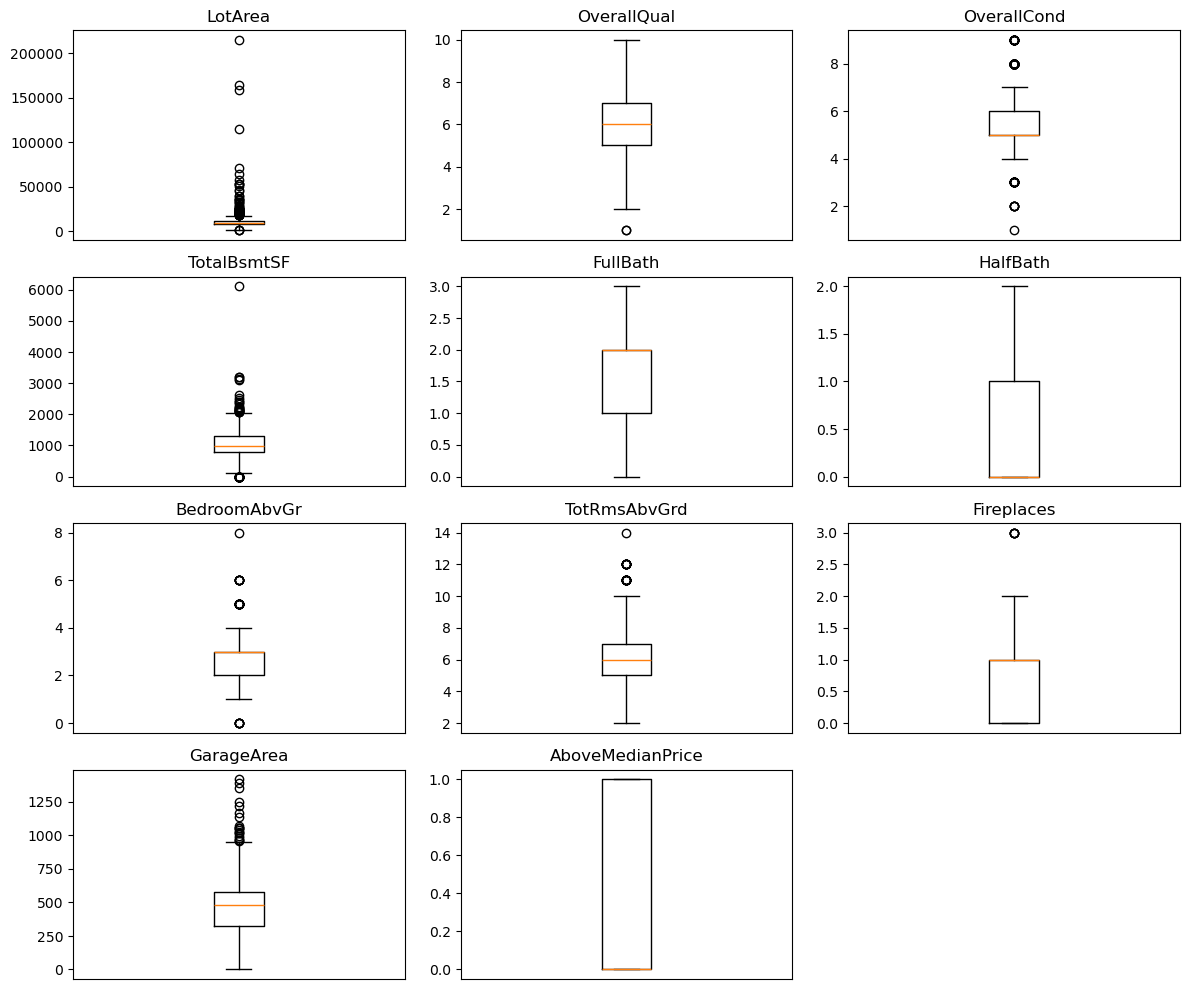

In [31]:
numeric_cols = house_df_clean.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    plt.boxplot(house_df[col])
    plt.title(col)
    plt.xticks([])

plt.tight_layout()
plt.show()

# 📈 Univariate Analyse

Statistische Kennzahlen und Verteilungen der Merkmale.

In [32]:
num_cols = house_df_clean.columns.drop("AboveMedianPrice")
house_df_clean[num_cols].describe().round(2)

,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageArea
count,1453.00,1453.00,1453.00,1453.00,1453.00,1453.00,1453.00,1453.00,1453.00,1453.00
mean,10542.66,6.10,5.58,1059.69,1.57,0.38,2.87,6.53,0.62,473.25
std,9997.12,1.38,1.11,437.73,0.55,0.50,0.81,1.62,0.64,214.27
min,1300.00,1.00,1.00,0.00,0.00,0.00,0.00,2.00,0.00,0.00
25%,7577.00,5.00,5.00,796.00,1.00,0.00,2.00,5.00,0.00,328.00
50%,9500.00,6.00,5.00,992.00,2.00,0.00,3.00,6.00,1.00,480.00
75%,11616.00,7.00,6.00,1300.00,2.00,1.00,3.00,7.00,1.00,576.00
max,215245.00,10.00,9.00,6110.00,3.00,2.00,8.00,14.00,3.00,1418.00


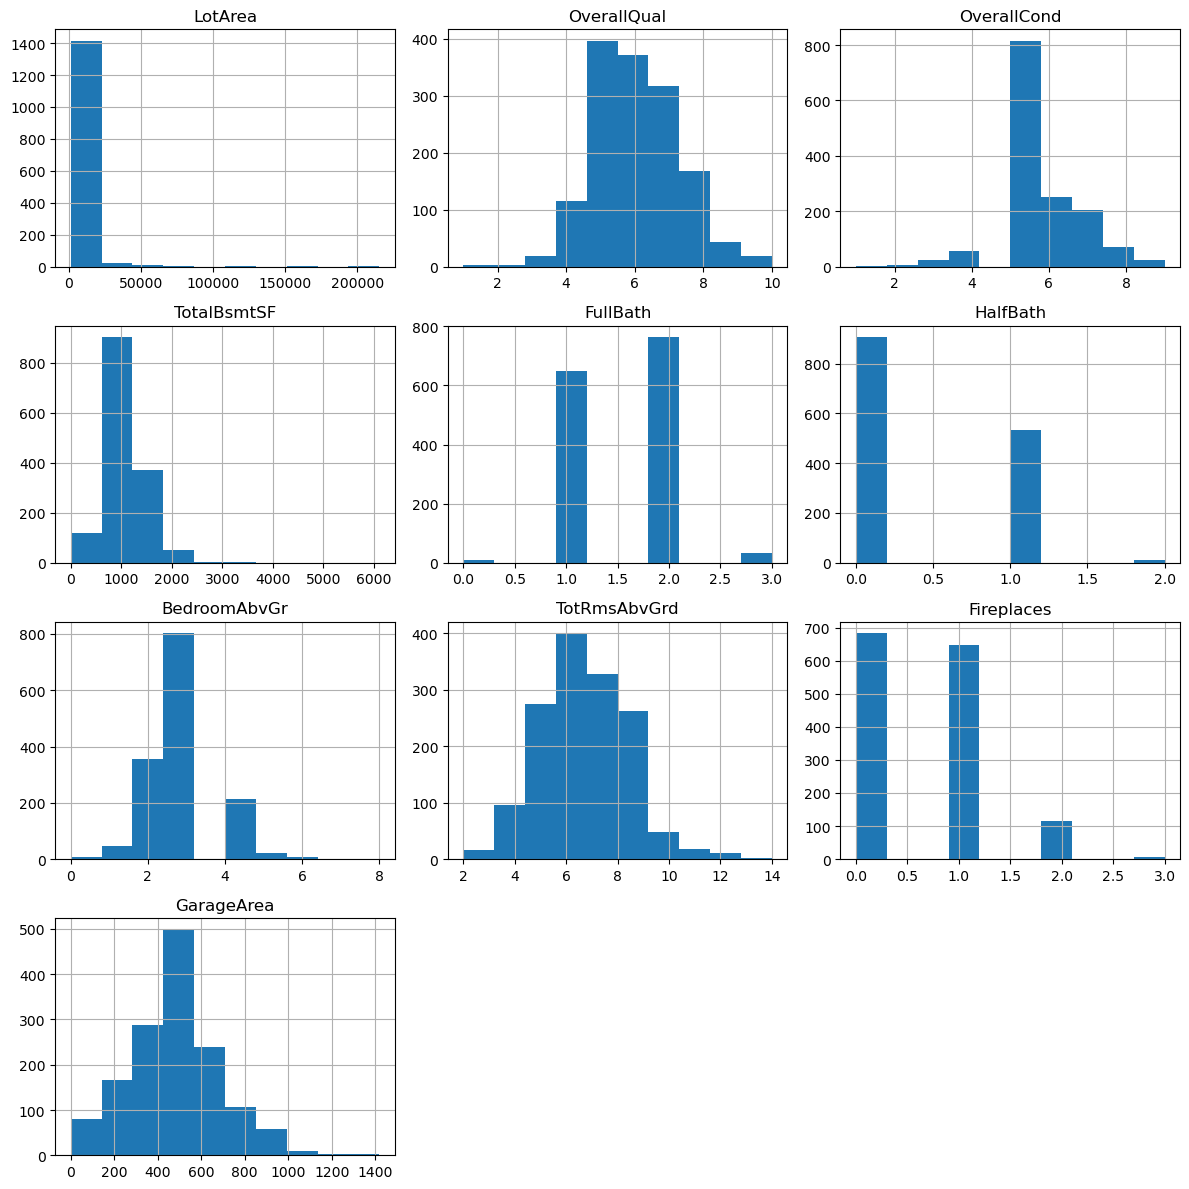

In [33]:
house_df_clean[num_cols].hist(figsize=(12,12))
plt.tight_layout()
plt.show()

Insgesamt zeigt die univariate Analyse, dass die Verteilungen der Merkmale realistische Marktstrukturen widerspiegeln.

# 🎯 Verteilung der Zielvariable

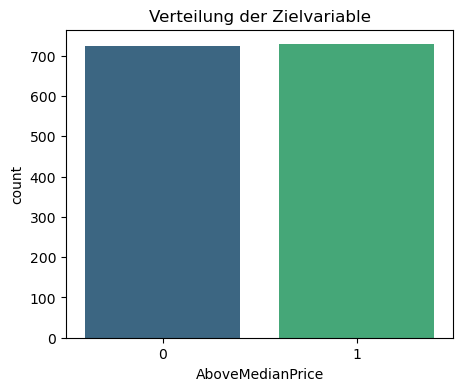

In [35]:
plt.figure(figsize = (5,4))
sns.countplot(
    data = house_df_clean,
    x="AboveMedianPrice",
    hue="AboveMedianPrice",  # notwenig, um palette zu nutzen
    palette="viridis",
    legend=False)
plt.title("Verteilung der Zielvariable")
plt.show()

Das Histogramm zeigt eine Gleichverteilung der Beobachtungen bei den beiden Ausprägungen der Zielvariablen: es gibt 728 Immobilien über dem Medianpreis und 725 Immobilien unter dem Medianpreis. Eine ausbalancierte Zielvariable ist sehr vorteilhaft für Klassifikationsaufgaben. Damit gibt es ausreichend Beobachtungen zu beiden Ausprägungen, um die Vorhersagemodelle zu trainieren.

# 🔍 Bivariate Analyse

Boxplots + Korrelationen zur Zielvariable.  
Sortiert nach prädiktiver Stärke.

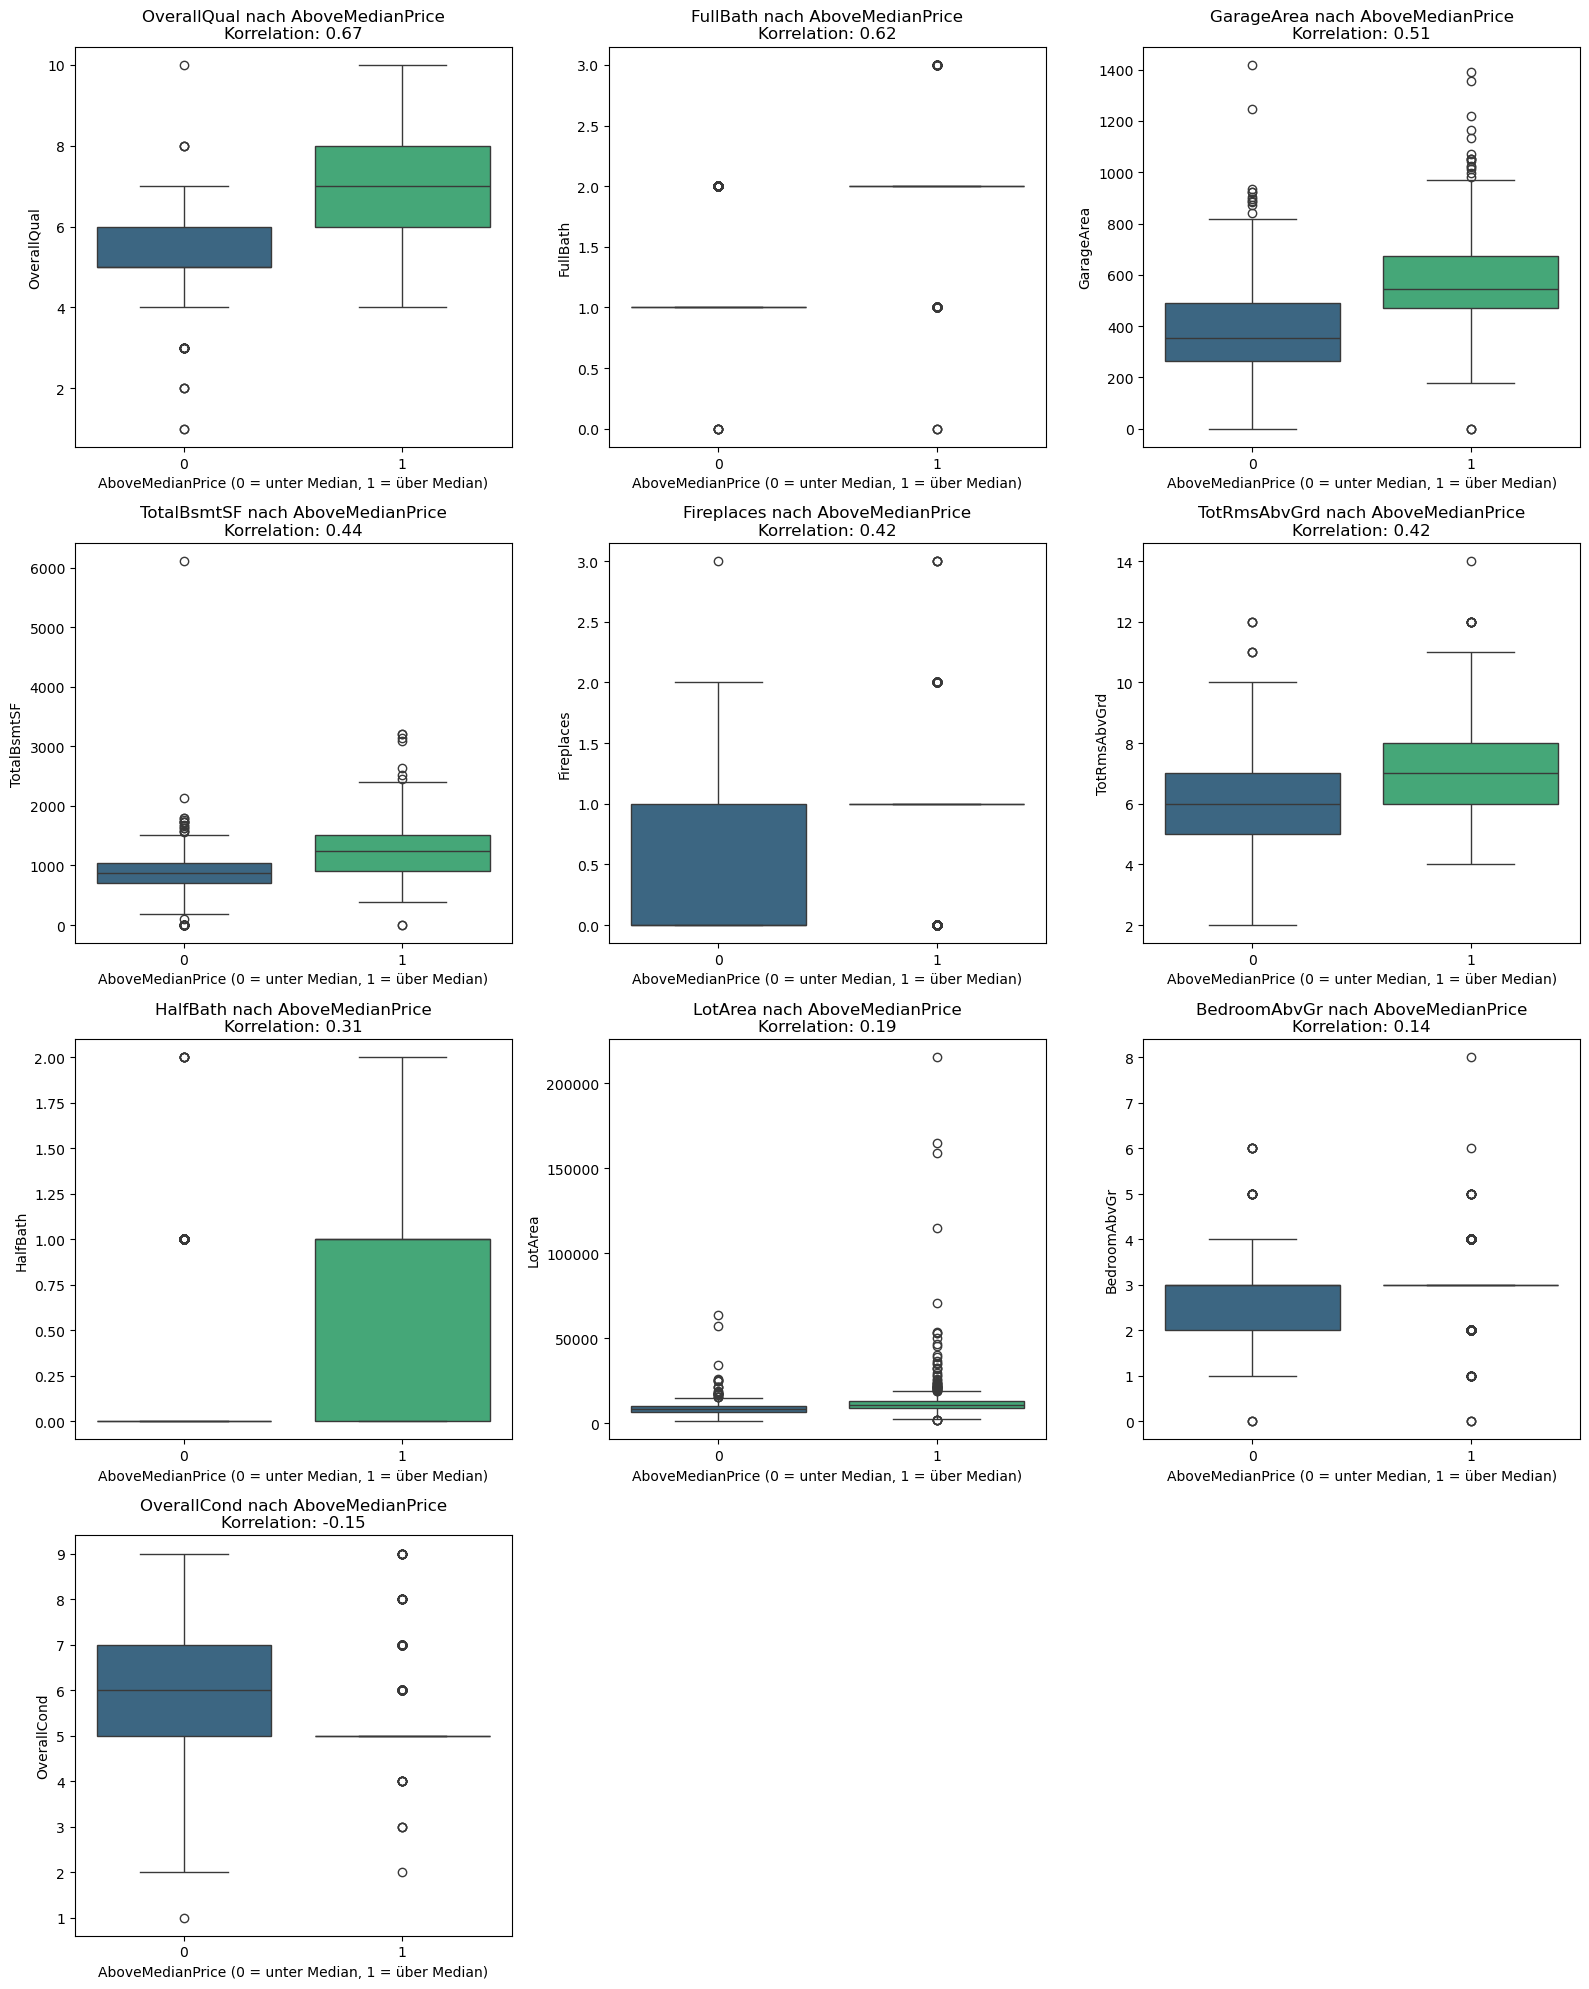

In [37]:
# Numerische Variablen außer der Zielvariable
num_cols = house_df_clean.columns.drop("AboveMedianPrice")
# Korrelationen zur Zielvariable in die Visualisierung integrieren
corr_target = house_df_clean.corr()["AboveMedianPrice"]

# Sortierte Variablenliste anhand Korrelationswerte (absteigend)
sorted_cols = corr_target.drop("AboveMedianPrice").sort_values(ascending=False).index

# Visualisierung
plt.figure(figsize=(16, 20))  # Layout festlegen

for i, col in enumerate(sorted_cols, 1):
    plt.subplot((len(num_cols) + 2) // 3, 3, i)
    sns.boxplot(
        data=house_df_clean,
        x="AboveMedianPrice", 
        y=col, 
        hue="AboveMedianPrice",  # notwenig, um palette zu nutzen
        palette="viridis",
    legend=False)   # Legende für die Übersichtlichkeit ausblenden
    plt.title(f"{col} nach AboveMedianPrice\nKorrelation: {corr_target[col]:.2f}")
    plt.xlabel("AboveMedianPrice (0 = unter Median, 1 = über Median)")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

**Kurzauswertung der bivariaten Analyse (Boxplots + Korrelationen)**

Die bivariate Analyse zeigt, wie sich die Verteilungen der einzelnen Merkmale zwischen den beiden Preisgruppen unterscheiden (0 = unter Medianpreis, 1 = über Medianpreis). Die Boxplots sind nach absteigender Korrelation sortiert und ermöglichen eine visuelle Einschätzung der prädiktiven Eigenschaften der Merkmale. Die Kombination aus Lageunterschieden, Überlappung und Korrelationswerten erlaubt eine Einordnung in starke, mittlere und schwache Prädiktoren.

**Zusammenfassung der prädiktiven Einordnung**

- **Stark prädiktiv:** OverallQual, FullBath, GarageArea, TotalBsmtSF, Fireplaces, TotRmsAbvGrd  
- **Mittel prädiktiv:** HalfBath  
- **Schwach oder nicht-linear prädiktiv:** LotArea, BedroomAbvGr, OverallCond  

Die Boxplots liefern damit eine klare visuelle Grundlage für die spätere Merkmalsselektion. Die Kombination aus Lageunterschieden, Überlappung und Korrelationswerten ermöglicht eine fundierte Einordnung der prädiktiven Eigenschaften der einzelnen Merkmale.

# 🔍 Multivariate Analyse

Heatmap mit Korrelationswerten

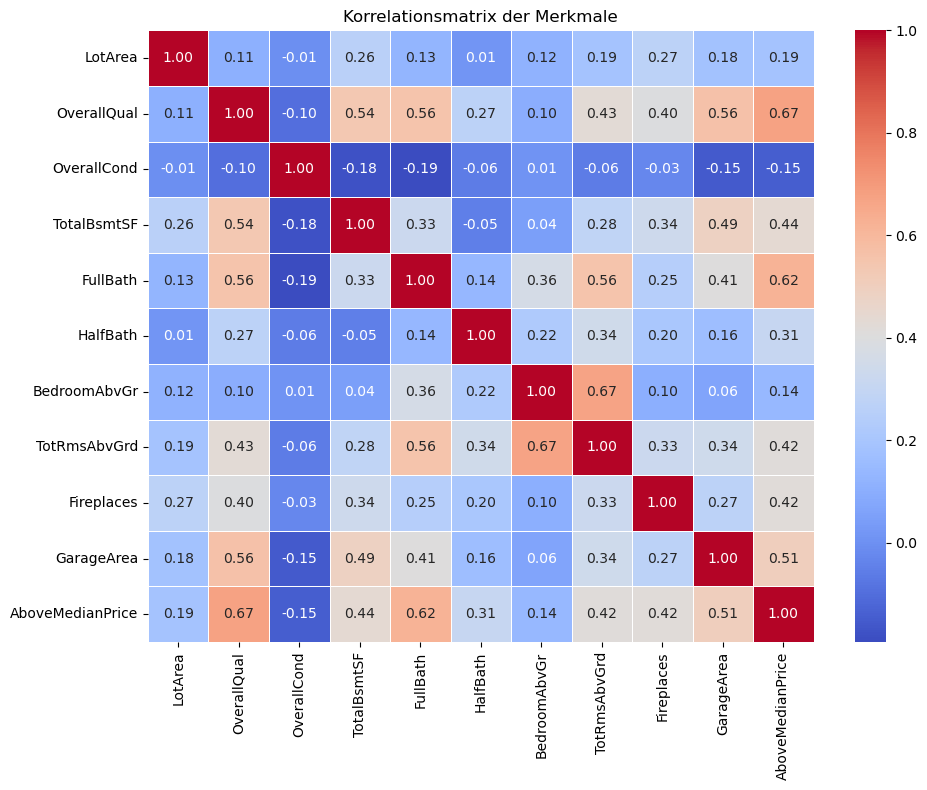

In [39]:
# Korrelationsmatrix berechnen
corr = house_df_clean.corr()

# Heatmap mit Korrelationswerten
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,            # Korrelationswerte einbinden
    cmap="coolwarm",
    linewidths=0.5,
    annot=True,      # Korrelationswerte in die Quadrate schreiben
    fmt=".2f"        # Formatierung der Zahlen
)
plt.title("Korrelationsmatrix der Merkmale")

plt.tight_layout()
plt.show()

Die Matrix zeigt eindeutig Multikollinearitäten in folgenden Variablen-Clustern:

- **Cluster A**: TotalBsmtSF  <-> OverallQual (0.54) und Garage Area (0.49)
  Diese Variablen messen Größe, Wertigkeit und Ausstattung des Hauses. Sie sind inhaltlich redundant.
- **Cluster B**: FullBath     <-> OverallQual (0.55) und TotRmsAbvGrd (0.55)
  Auch besteht eine inhaltliche Redundanz: Mehr Räume, also auch mehr Badezimmer führen zu höherer Qualität.
- **Cluster C**: BedroomAbvGr <-> TotRmsAbvGrd (0.68)
  TotRmsAbvGrd enthält BedroomAbvGrd bereits. Also besteht auch hier Redundanz.

Die Zusammenhänge erklären sich auch intuitiv. OverallQual ist  ein "Meta-Merkmal", das andere Merkmale enthält und möglicherweise subjektive Aspekte (bspw. durch den Immobilien-Gutachter) einschließt. Diese Merkmal erzeugt starke Kollinearität und andere Merkmal treten dadurch in den Hintergrund. Auch die Merkmale TotRmsAbvGrd und TotalBsmtSF führen zu starker Kollinearität, da sie andere Merkmale enthalten. Durch Reduktion der Prädikatorenliste um die vorgenannten Merkmal, würde ein nicht-redundanter Merkmalsraum entstehen.

# 🧩 Modellvorbereitung

- Merkmalsmatrix X  
- Zielvariable y  
- Train-Test-Split  
- Skalierung für LogReg & KNN & RandomForest

In [40]:
# Auswahl Prädikatoren + Zielvariable
features = ["FullBath", "GarageArea", "Fireplaces", "LotArea", "HalfBath"]
target = "AboveMedianPrice"

X = house_df_clean[features]
y = house_df_clean[target]

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y
)

# Standardisierung für skalenempfindliche Verfahren
scaler = StandardScaler()     
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🤖 Modellbildung

Wir trainieren:
- Logistische Regression  
- KNN  
- Random Forest  

In [42]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    results[name] = accuracy_score(y_test, preds)

results

{'Logistic Regression': 0.8625429553264605,
 'KNN': 0.8487972508591065,
 'Random Forest': 0.8797250859106529}

# 📉 Confusion Matrix (Bestes Modell)

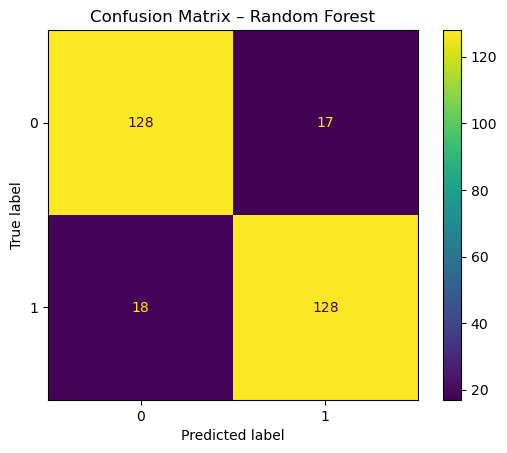

In [44]:
best_model = RandomForestClassifier(n_estimators=200, random_state=42)
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="viridis")
plt.title("Confusion Matrix – Random Forest")
plt.show()

# ⭐ Feature Importance (Random Forest)

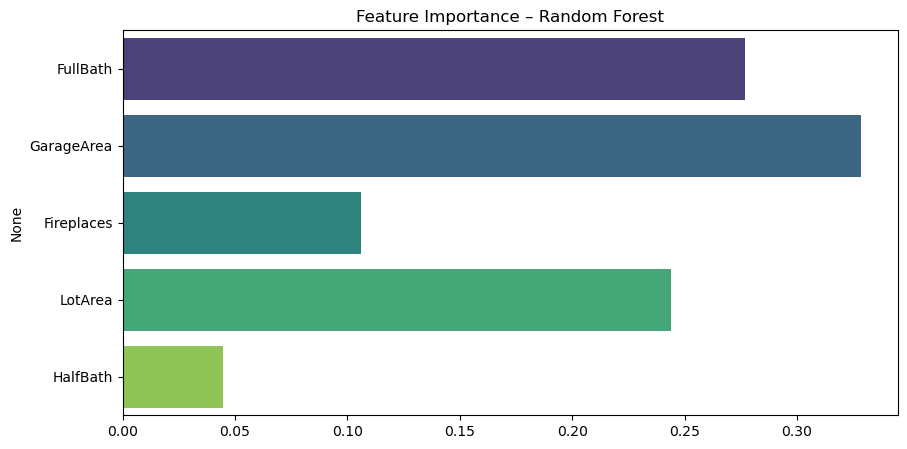

In [47]:
importances = best_model.feature_importances_

plt.figure(figsize=(10,5))
sns.barplot(
    x=importances,
    y=X.columns,
    hue=X.columns,          # notwendig für zukünftige seaborn-Versionen
    palette="viridis",
    legend=False            # verhindert doppelte Legende
)
plt.title("Feature Importance – Random Forest")
plt.show()

# 🚀 Fazit (Kurzversion)

- Random Forest liefert die beste Performance.  
- Starke Prädiktoren: OverallQual, FullBath, GarageArea, TotalBsmtSF.  
- Der Workflow entspricht Aufgabe 3 (WEB78), jedoch in komprimierter Form.  